# Approximate Hybrid Quantum State Preparation for a Single-Gaussian Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## Signal Generation

A single-Gaussian signal is generated as a representative smooth localized waveform for transform-domain sparsity analysis.

In [3]:
n = 15 # Number of qubit
N = 2**n  # Number of quantum basis

x  = np.linspace(-5, 5, N)
mu, sigma, amp = 0.0, 0.8, 1.0
g = amp * np.exp(-(x - mu)**2 / (2.0 * sigma**2))

target_f =  g / np.linalg.norm(g)

## Visualization of Single-Gaussian Signal

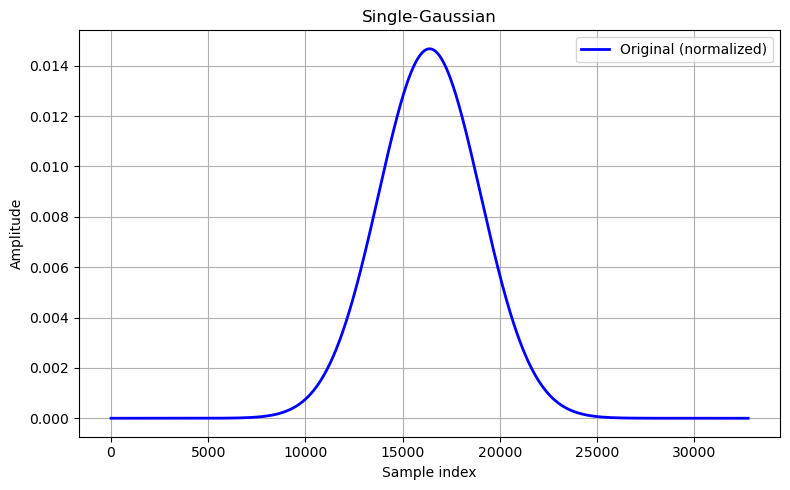

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Single-Gaussian")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Phase I: Classical Compression

### Classical Sparsity Analysis

In [5]:
results = search_sparse_haar_representations(
    g,
    tolerance=0.04
)

Level=7 | Threshold=1.131e-02 | Nonzero=406 | Sparsity=0.012 | Trace Distance=1.665517e-03 | Fidelity=0.999997
Level=7 | Threshold=2.262e-02 | Nonzero=294 | Sparsity=0.009 | Trace Distance=3.169562e-03 | Fidelity=0.999990
Level=7 | Threshold=5.655e-02 | Nonzero=184 | Sparsity=0.006 | Trace Distance=6.560219e-03 | Fidelity=0.999957
Level=7 | Threshold=1.131e-01 | Nonzero=124 | Sparsity=0.004 | Trace Distance=1.085636e-02 | Fidelity=0.999882
Level=7 | Threshold=2.262e-01 | Nonzero=114 | Sparsity=0.003 | Trace Distance=1.349003e-02 | Fidelity=0.999818
Level=7 | Threshold=5.655e-01 | Nonzero=100 | Sparsity=0.003 | Trace Distance=2.556209e-02 | Fidelity=0.999347
Level=8 | Threshold=1.597e-02 | Nonzero=262 | Sparsity=0.008 | Trace Distance=1.761180e-03 | Fidelity=0.999997
Level=8 | Threshold=3.195e-02 | Nonzero=198 | Sparsity=0.006 | Trace Distance=3.378873e-03 | Fidelity=0.999989
Level=8 | Threshold=7.987e-02 | Nonzero=130 | Sparsity=0.004 | Trace Distance=7.433201e-03 | Fidelity=0.999945
L

In [6]:
# Apply 10-level discrete packet Haar wavelet transformation on Single-Gaussian signal
level = 13
X = haar_packet_transform(g, level)

In [7]:
# apply top-k threshold on the transformed data for k =44
k = 44
Xr = top_k_threshold(X, k)

### Normalization

In [8]:
X_norm = Xr/np.linalg.norm(Xr)

### Classical Signal Reconstruction

In [9]:
x_rec = inverse_haar_packet_transform(X_norm, level)

### Trace Distance

In [10]:
TD = trace_distance(x_rec, target_f)

### Visualization

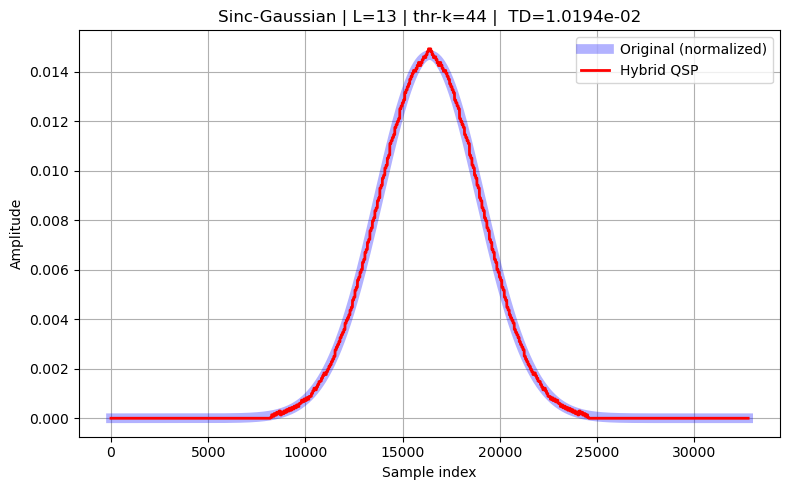

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(x_rec, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Sinc-Gaussian | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.savefig("../figures/Single-Gaussian_signal_Preparation.pdf")
plt.show()

## Phase II: Quantum Decompression
The sparse Haar-domain representation is normalized and encoded into a quantum state. The inverse Quantum Packet Haar Wavelet Transform is then applied in order to reconstruct the original signal quantum mechanically.

In [12]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [13]:
vec = X_norm

# Nonzero indices
nz = np.flatnonzero(vec)

# Number of qubits
nqubits = int(np.log2(len(vec)))

y = [(format(i, f"0{nqubits}b"), vec[i]) for i in nz]

qc = sparse_encoder(y, method="farias")


iqphwt = build_inverse_qphwt_circuit(
    n=nqubits,
    level=level
)

qc.add(iqphwt.on_qubits(*range(nqubits)))

print(qc.decompose().decompose().summary())

[Qibo 0.3.3|INFO|2026-05-28 12:25:52]: Using numpy backend on /CPU:0


Circuit depth = 382
Total number of gates = 795
Number of qubits = 15
Most common gates:
cx: 522
x: 165
ry: 79
h: 29
None


## Statevector of the Quantum SQSP and Quantum Decompression

In [14]:
result = qc()

state = result.state()

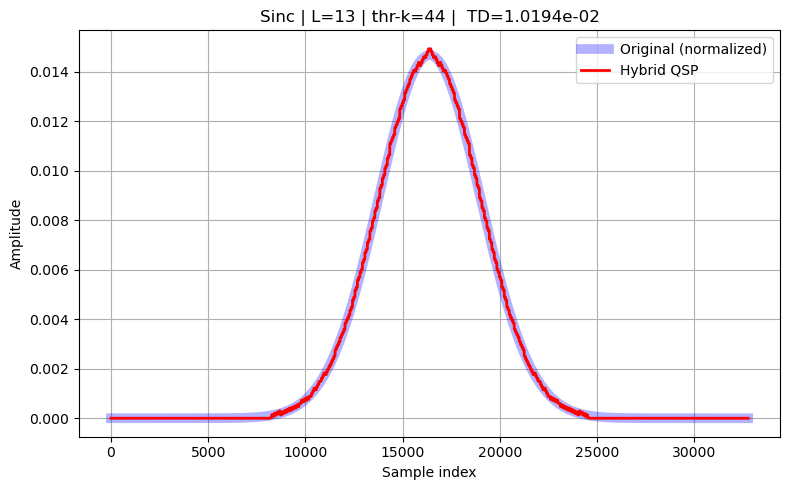

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(state.real, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Sinc | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()